In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# importing the first essential datasets

In [ ]:
df = pd.read_csv("train.csv")
# Loading the dataset with pandas

/tmp/ipykernel_231/583525767.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv")


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
#here we are converting the date column from text to readable data to pandas
df = df[df["Store"] == 1]
df = df[df["Open"]==1]

df = df.sort_values("Date")
#sorting all the date values accordigly
df.set_index("Date",inplace = True)
#for time series models it is better for it to predict if the data is[Time --> Value]

In [ ]:
train = df.iloc[:-90]
#the data before the last 90 days
test = df.iloc[-90:]
#testing the data after the 90 days

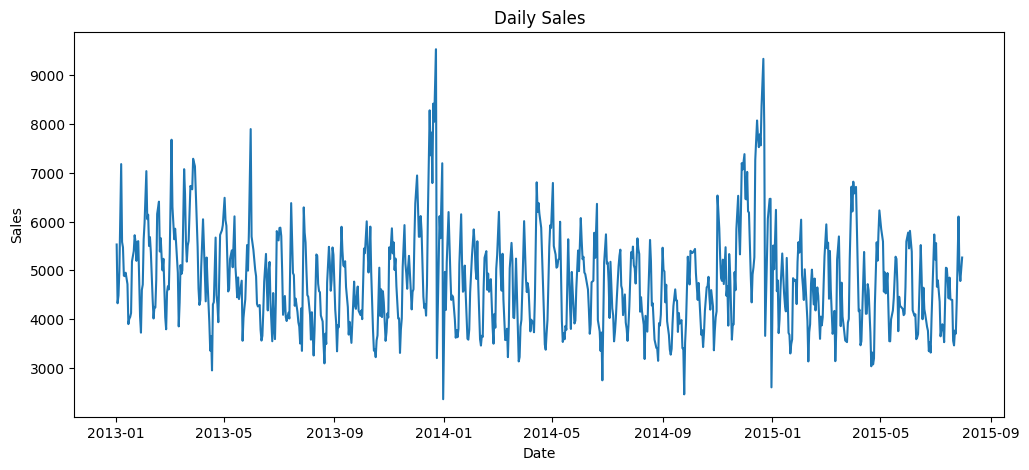

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df["Sales"])

plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()
# here we are seeing the daily sales

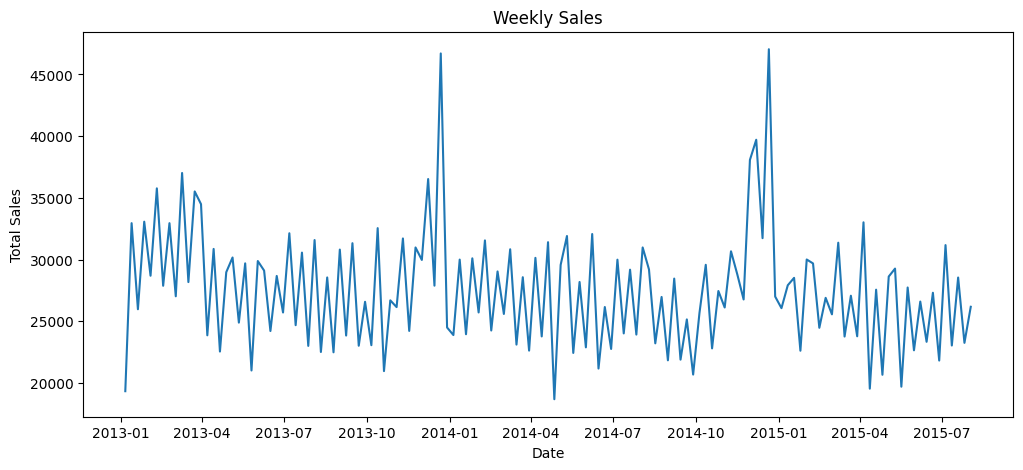

In [ ]:
weekly_sales = df["Sales"].resample("W").sum()

plt.figure(figsize=(12,5))

plt.plot(weekly_sales)

plt.title("Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()
#weekly sales

/tmp/ipykernel_231/396642365.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df["Sales"].resample("M").sum()


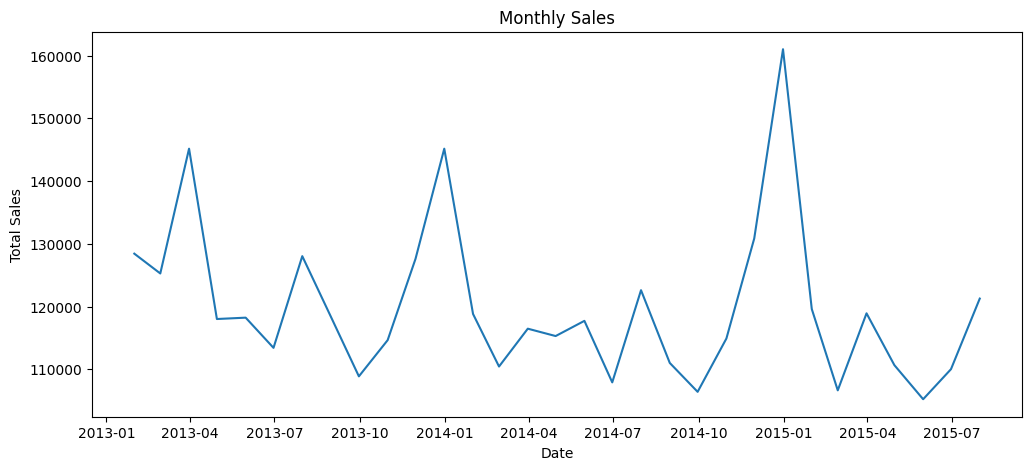

In [ ]:
monthly_sales = df["Sales"].resample("M").sum()

plt.figure(figsize=(12,5))

plt.plot(monthly_sales)

plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()
#montly sales

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarimax_model = SARIMAX(
    train["Sales"],
    order = (1,1,1),
    seasonal_order= (1,1,1,7)
)
sarimax_result = sarimax_model.fit()
#training the model with sarimax

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
sarimax_forecast = sarimax_result.forecast(steps=90)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

sarimax_mae = mean_absolute_error(test["Sales"], sarimax_forecast)

sarimax_rmse = np.sqrt(
    mean_squared_error(test["Sales"], sarimax_forecast)
)

print("SARIMAX MAE:", sarimax_mae)
print("SARIMAX RMSE:", sarimax_rmse)

SARIMAX MAE: 688.2007769150605
SARIMAX RMSE: 804.9228373060317


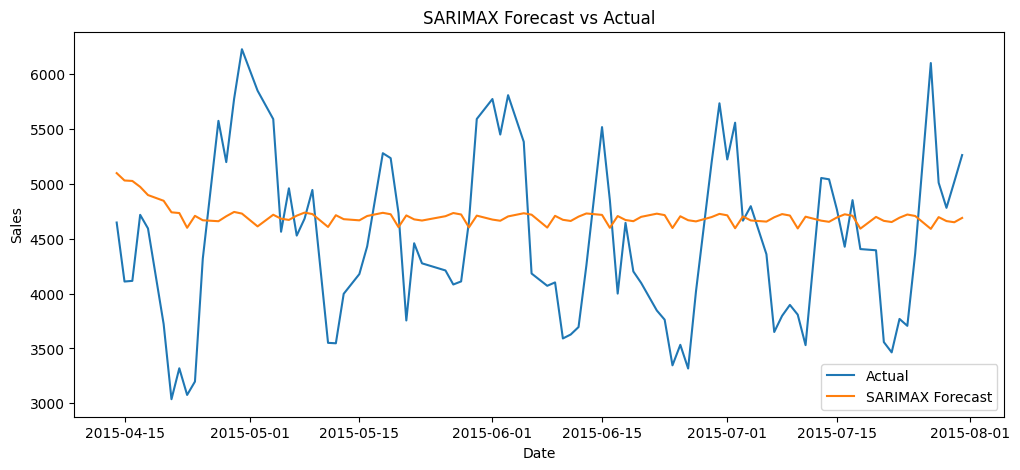

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test["Sales"], label="Actual")
plt.plot(test.index, sarimax_forecast, label="SARIMAX Forecast")

plt.title("SARIMAX Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()
#actual vs the predicted data

In [ ]:
from prophet import Prophet

In [ ]:
df2 = df.reset_index()[["Date","Sales"]]
df2.columns = ["ds","y"]

In [ ]:
prophet_model = Prophet()

prophet_model.fit(df2)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = prophet_model.make_future_dataframe(periods=90)

In [ ]:
forecast = prophet_model.predict(future)

In [ ]:
prophet_forecast = forecast.set_index("ds")

prophet_test = prophet_forecast.loc[test.index]["yhat"]

In [ ]:
prophet_mae = mean_absolute_error(test["Sales"],prophet_test)

prophet_rmse = np.sqrt(
    mean_squared_error(test["Sales"],prophet_test))

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)

Prophet MAE: 627.6302637149007
Prophet RMSE: 749.78373965165


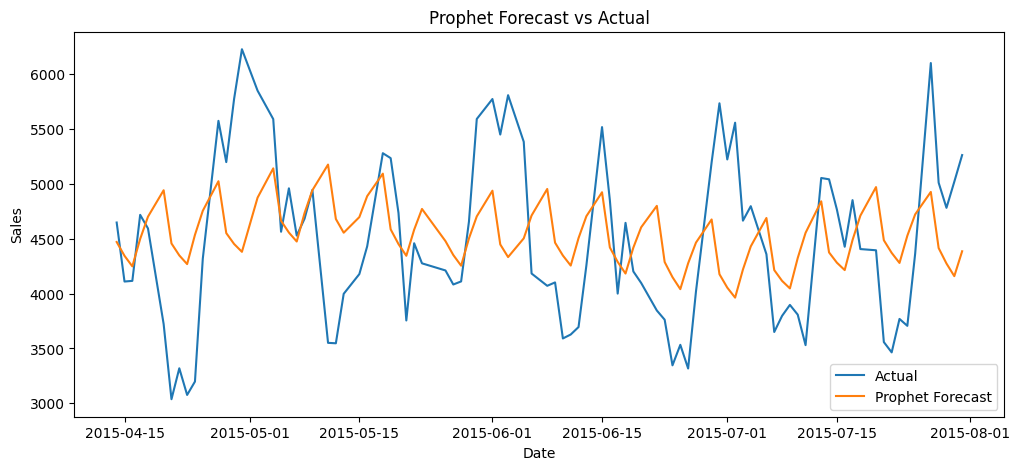

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test["Sales"], label="Actual")
plt.plot(test.index, prophet_test, label="Prophet Forecast")

plt.title("Prophet Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [ ]:
from xgboost import XGBRegressor

In [ ]:
df3 = df.copy()

df3["dayofweek"] = df3.index.dayofweek
df3["month"] = df3.index.month
df3["year"] = df3.index.year

df3["lag1"] = df3["Sales"].shift(1)
df3["lag7"] = df3["Sales"].shift(7)
df3["lag30"] = df3["Sales"].shift(30)

df3 = df3.dropna()
#feature engineering

In [ ]:
features = [
    "dayofweek",
    "month",
    "year",
    "lag1",
    "lag7",
    "lag30"
]

X = df3[features]
y = df3["Sales"]

In [ ]:
split = len(df3) - 90

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_forecast = xgb_model.predict(X_test)

In [ ]:
xgb_mae = mean_absolute_error(y_test, xgb_forecast)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_forecast)
)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 395.52978515625
XGBoost RMSE: 496.7861555790378


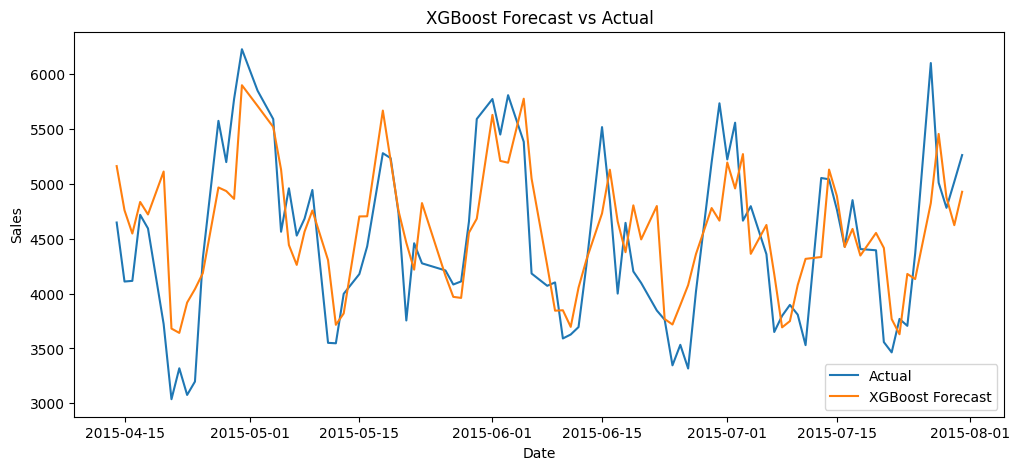

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, xgb_forecast, label="XGBoost Forecast")

plt.title("XGBoost Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

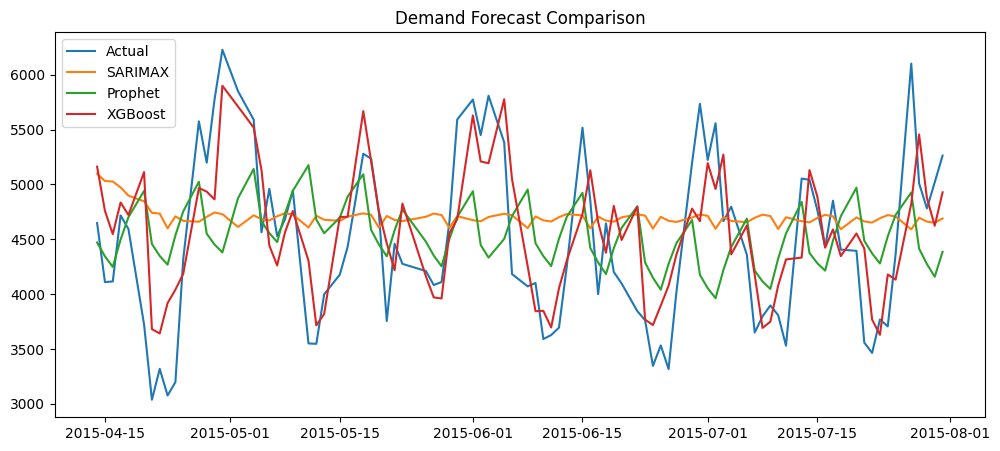

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test["Sales"], label="Actual")
plt.plot(test.index, sarimax_forecast, label="SARIMAX")
plt.plot(test.index, prophet_test, label="Prophet")
plt.plot(test.index, xgb_forecast, label="XGBoost")

plt.legend()
plt.title("Demand Forecast Comparison")
plt.show()

In [ ]:
print("Model Comparison")
print("SARIMAX RMSE:", sarimax_rmse)
print("Prophet RMSE:", prophet_rmse)
print("XGBoost RMSE:", xgb_rmse)

Model Comparison
SARIMAX RMSE: 804.9228373060317
Prophet RMSE: 749.78373965165
XGBoost RMSE: 496.7861555790378


In [ ]:
import joblib

In [ ]:
joblib.dump(prophet_model,'prophet_model.pkl')
joblib.dump(sarimax_model,'sarimax_model.pkl')
joblib.dump(xgb_model, 'xgboost_model.pkl')

['sarimax_model.pkl']